In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import seaborn as sbs
import matplotlib.pyplot as plt
from matplotlib import colors
import tensorflow as tf
import keras as keras
import sklearn.model_selection
from keras.layers import Dense, Flatten
from matplotlib import pyplot as plt
from keras.models import Sequential
from matplotlib.ticker import PercentFormatter
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from keras.datasets import mnist
from keras.utils import to_categorical
from keras.layers.normalization.layer_normalization import *
from keras.layers.normalization.batch_normalization import *
from sklearn import preprocessing
from sklearn import utils
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score  
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import plotly.express as px
import csv
plt.style.use('seaborn')

In [2]:
df = pd.read_csv(r'occupancy.csv')
df.dropna(inplace=True)
df

,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,2015-02-02 14:19:00,23.700000,26.272000,585.200000,749.200000,0.004764,1
1,2015-02-02 14:19:59,23.718000,26.290000,578.400000,760.400000,0.004773,1
2,2015-02-02 14:21:00,23.730000,26.230000,572.666667,769.666667,0.004765,1
3,2015-02-02 14:22:00,23.722500,26.125000,493.750000,774.750000,0.004744,1
4,2015-02-02 14:23:00,23.754000,26.200000,488.600000,779.000000,0.004767,1
...,...,...,...,...,...,...,...
2660,2015-02-04 10:38:59,24.290000,25.700000,808.000000,1150.250000,0.004829,1
2661,2015-02-04 10:40:00,24.330000,25.736000,809.800000,1129.200000,0.004848,1
2662,2015-02-04 10:40:59,24.330000,25.700000,817.000000,1125.800000,0.004841,1
2663,2015-02-04 10:41:59,24.356667,25.700000,813.000000,1123.000000,0.004849,1


In [3]:
df.drop('date', axis=1, inplace=True)
df['Humidity'] = np.round(df['Humidity'], decimals = 3)
df['Temperature'] = np.round(df['Temperature'], decimals = 2)
df['Light'] = np.round(df['Light'], decimals = 2)
df['CO2'] = np.round(df['CO2'], decimals = 2)
df.drop(df.index[range(80)], inplace=True)

In [4]:
df.drop(df.index[range(190, 2585)], inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,23.20,28.650,469.0,1124.25,0.005043,1
1,23.20,28.620,469.0,1130.40,0.005038,1
2,23.20,28.700,464.0,1138.00,0.005052,1
3,23.20,28.700,456.5,1144.00,0.005052,1
4,23.20,28.718,457.0,1140.00,0.005055,1
...,...,...,...,...,...,...
185,21.77,24.390,0.0,687.00,0.003928,0
186,21.77,24.365,0.0,679.75,0.003924,0
187,21.75,24.350,0.0,668.40,0.003919,0
188,21.70,24.290,0.0,665.67,0.003896,0


/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


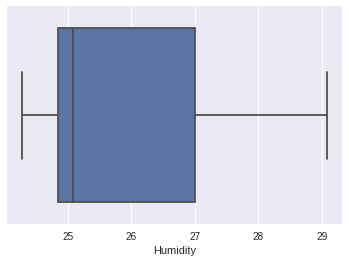

In [5]:
plt.figure(figsize=(6,4))
sns.boxplot(df['Humidity'])
plt.show()

In [6]:
print("Min values:")
print(df.min())
print("Max values:")
print(df.max())
print("Average values:")
print(df.mean())
print("Standard deviation:")
print(df.std())
print("Median:")
print(df.median())
print("IQRs:")

def removeOutliers(df, col):

    Q3 = np.quantile(df[col], 0.75)
    Q1 = np.quantile(df[col], 0.25)
    IQR = Q3 - Q1
 
    print("IQR value for column %s is: %s" % (col, IQR))

    global outlier_free_list
    global filtered_data
 
    lower_range = Q1 - 1.5 * IQR
    upper_range = Q3 + 1.5 * IQR
    outlier_free_list = [x for x in df[col] if (
        (x > lower_range) & (x < upper_range))]
    filtered_data = df.loc[df[col].isin(outlier_free_list)]


for i in df.columns:
  #if i == df.columns[0]:
    removeOutliers(df, i)
  #else:
    #removeOutliers(filtered_data, i)

#df = filtered_data
#print(filtered_data.shape)

Min values:
Temperature       21.700000
Humidity          24.290000
Light              0.000000
CO2              664.750000
HumidityRatio      0.003896
Occupancy          0.000000
dtype: float64
Max values:
Temperature        23.200000
Humidity           29.075000
Light             469.000000
CO2              1176.170000
HumidityRatio       0.005088
Occupancy           1.000000
dtype: float64
Average values:
Temperature       22.561368
Humidity          25.863237
Light            332.082947
CO2              885.137368
HumidityRatio      0.004381
Occupancy          0.647368
dtype: float64
Standard deviation:
Temperature        0.359727
Humidity           1.445232
Light            183.212627
CO2              140.312747
HumidityRatio      0.000336
Occupancy          0.479052
dtype: float64
Median:
Temperature       22.600000
Humidity          25.086000
Light            429.000000
CO2              837.100000
HumidityRatio      0.004248
Occupancy          1.000000
dtype: float64
IQRs:
IQR v

In [7]:
df.quantile([.1, .9])

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0.1,22.063,24.6225,0.0,716.540,0.004044,0.0
0.9,23.011,28.1397,444.0,1089.773,0.004887,1.0


/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


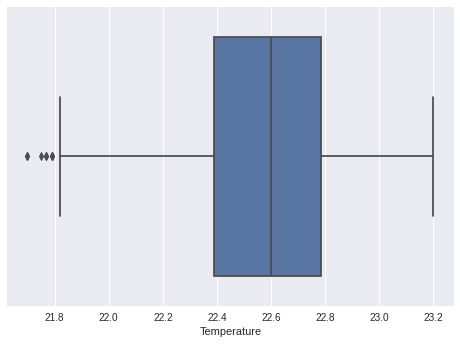

In [8]:
sns.boxplot(df['Temperature'])

In [9]:
print("Distant points:")
print(np.where(df['Temperature'] > 23.2))
print(np.where(df['Temperature'] < 21.8))

Distant points:
(array([], dtype=int64),)
(array([182, 183, 184, 185, 186, 187, 188, 189]),)


/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


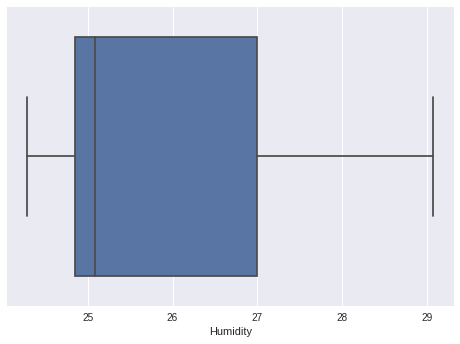

In [10]:
sns.boxplot(df['Humidity'])

In [11]:
print(np.where(df['Humidity'] > 29.1))
print(np.where(df['Humidity'] < 24.2))

(array([], dtype=int64),)
(array([], dtype=int64),)


/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


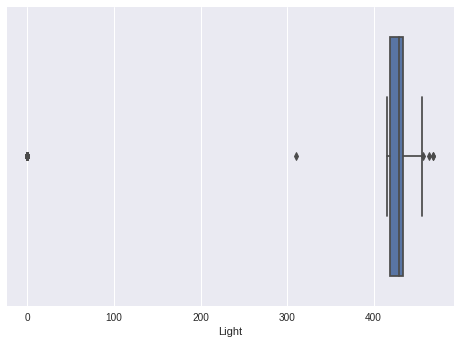

In [12]:
sns.boxplot(df['Light'])

In [13]:
print(np.where(df['Light'] > 460))
print(np.where(df['Light'] < 400))

(array([0, 1, 2]),)
(array([145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157,
       158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170,
       171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183,
       184, 185, 186, 187, 188, 189]),)


/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


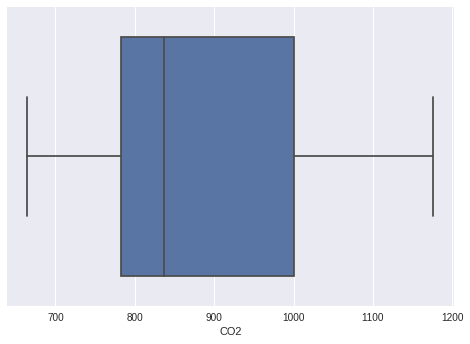

In [14]:
sns.boxplot(df['CO2'])

In [15]:
print(np.where(df['CO2'] > 1190))
print(np.where(df['CO2'] < 640))

(array([], dtype=int64),)
(array([], dtype=int64),)


/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


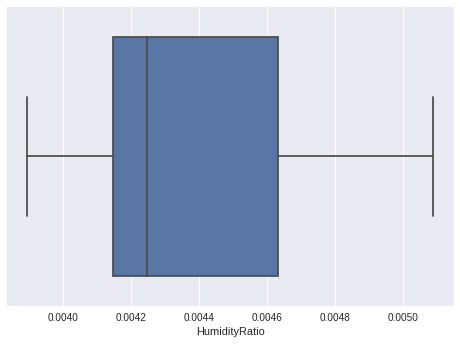

In [16]:
sns.boxplot(df['HumidityRatio'])

In [17]:
print(np.where(df['CO2'] > 0.0051))
print(np.where(df['CO2'] < 0.0038))

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 1

In [18]:
print(df.corr(method='pearson'))
c = df.corr().abs()

print("\nStrongest correlation:")
s = c.unstack()
so = s.sort_values(kind="quicksort")
print(so)

               Temperature  Humidity     Light       CO2  HumidityRatio  \
Temperature       1.000000  0.859317  0.800233  0.938507       0.919673   
Humidity          0.859317  1.000000  0.488469  0.977185       0.991053   
Light             0.800233  0.488469  1.000000  0.634638       0.582406   
CO2               0.938507  0.977185  0.634638  1.000000       0.993790   
HumidityRatio     0.919673  0.991053  0.582406  0.993790       1.000000   
Occupancy         0.733550  0.567967  0.757674  0.655886       0.625458   

               Occupancy  
Temperature     0.733550  
Humidity        0.567967  
Light           0.757674  
CO2             0.655886  
HumidityRatio   0.625458  
Occupancy       1.000000  

Strongest correlation:
Humidity       Light            0.488469
Light          Humidity         0.488469
Occupancy      Humidity         0.567967
Humidity       Occupancy        0.567967
HumidityRatio  Light            0.582406
Light          HumidityRatio    0.582406
HumidityRatio  

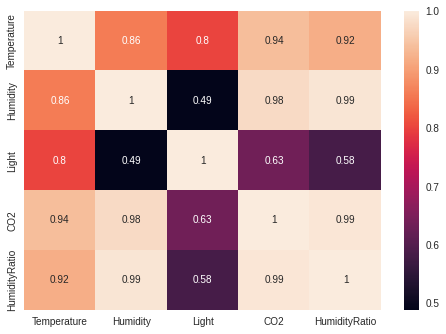

In [19]:
features = ['Temperature', 'Humidity', 'Light', 'CO2',	'HumidityRatio']

sbs.heatmap(df[features].corr(method='pearson'), annot=True)

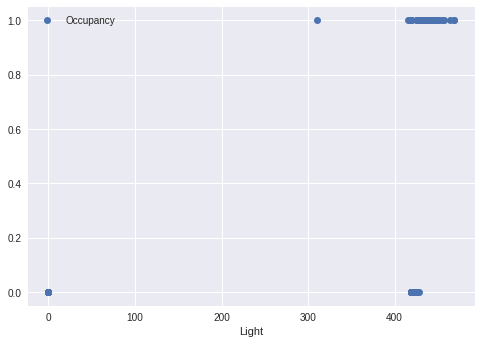

In [20]:
df.plot(x='Light', y='Occupancy', style='o')

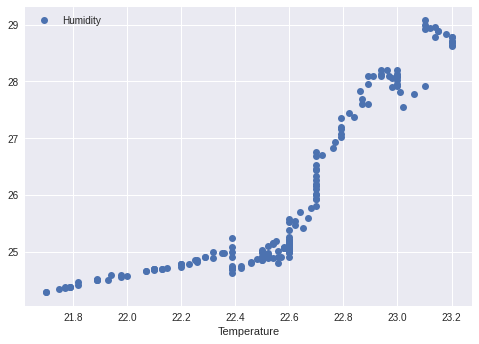

In [21]:
df.plot(x='Temperature', y='Humidity', style='o')

/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


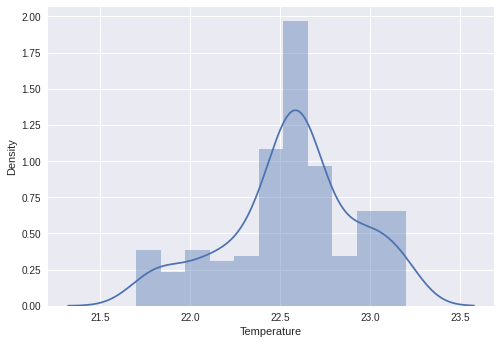

In [22]:
sns.distplot(df['Temperature'])

/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


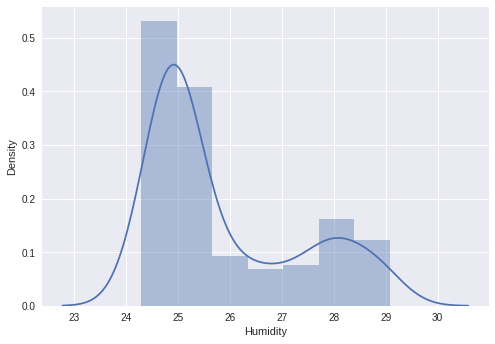

In [23]:
sns.distplot(df['Humidity'])

/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


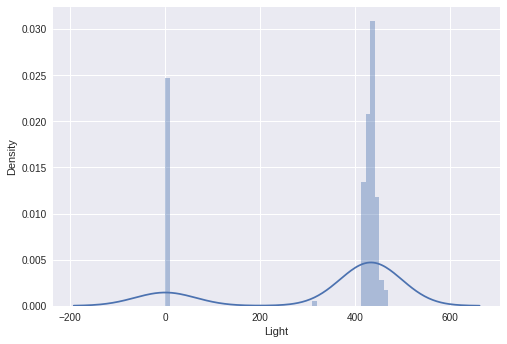

In [24]:
sns.distplot(df['Light'])

/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


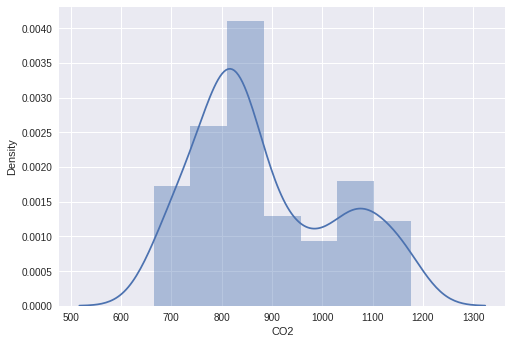

In [25]:
sns.distplot(df['CO2'])

/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


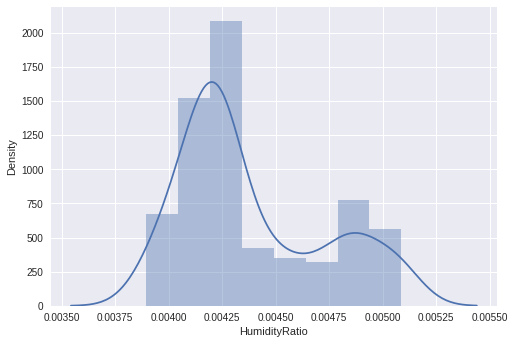

In [26]:
sns.distplot(df['HumidityRatio'])

In [27]:
x1 = df['Temperature'].values.reshape(-1, 1)
y1 = df['Humidity'].values.reshape(-1, 1)

x2 = df['Light'].values.reshape(-1, 1)
y2 = df['CO2'].values.reshape(-1, 1)

In [ ]:
x_train1, x_test1, y_train1, y_test1 = train_test_split(x1, y1, test_size=0.2)
x_train2, x_test2, y_train2, y_test2 = train_test_split(x2, y2, test_size=0.2)

model1 = LinearRegression()
model1.fit(x_train1, y_train1)

model2 = LinearRegression()
model2.fit(x_train2, y_train2)

y_pred1 = model1.predict(x_test1)
y_pred2 = model2.predict(x_test2)

pred_result1 = pd.DataFrame({'Actual': y_test1.flatten(), 'Prediction': y_pred1.flatten()})
pred_result1

In [71]:
model1.intercept_

array([-50.90310044])

In [72]:
model1.coef_

array([[3.40310646]])

In [73]:
model2.intercept_

array([726.35772954])

In [74]:
model2.coef_

array([[0.46689505]])

In [29]:
pred_result2 = pd.DataFrame({'Actual': y_test2.flatten(), 'Prediction': y_pred2.flatten()})
pred_result2

,Actual,Prediction
0,1064.60,926.655704
1,732.67,726.357730
2,834.25,925.255019
3,811.50,928.523285
4,830.75,928.523285
5,945.00,933.659130
6,716.00,726.357730
7,769.33,726.357730
8,1087.50,926.655704
9,706.67,726.357730


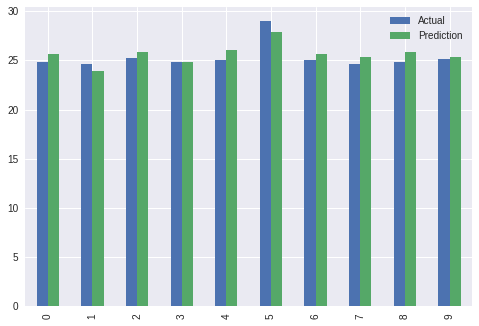

In [30]:
pred_chart1 = pred_result1.head(10)
pred_chart1.plot(kind='bar')

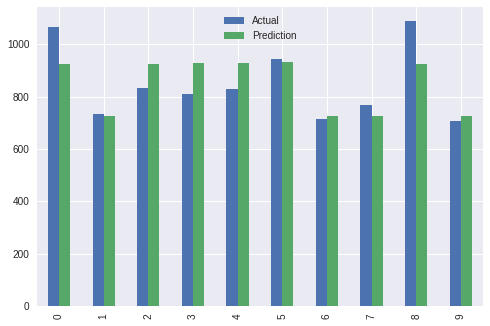

In [31]:
pred_chart2 = pred_result2.head(10)
pred_chart2.plot(kind='bar')

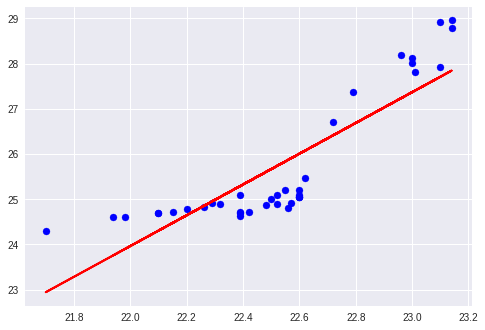

In [32]:
# humidity, temperature
plt.scatter(x_test1, y_test1, color='blue')
plt.plot(x_test1, y_pred1, color='red', linewidth=2)
plt.show()

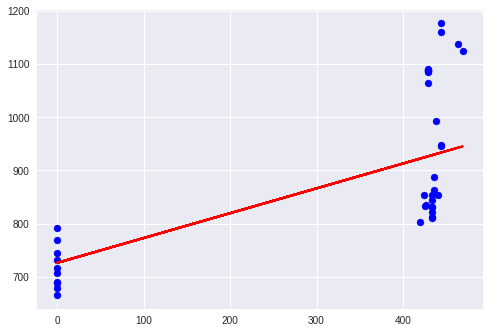

In [33]:
# co2, light
plt.scatter(x_test2, y_test2, color='blue')
plt.plot(x_test2, y_pred2, color='red', linewidth=2)
plt.show()

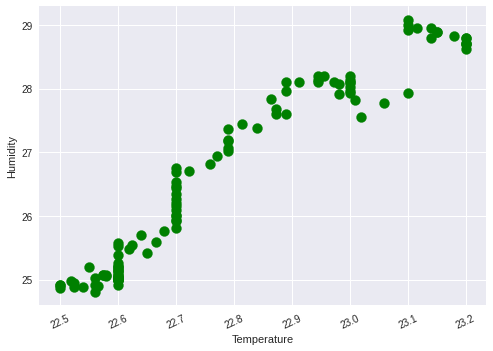

In [34]:
x = []
y = []
  
with open('occupancy.csv','r') as csvfile:
    numberOflines = len([line for line in csvfile])
    csvfile.seek(0)
    r = csv.reader(csvfile)
    next(r, None)
    for index, row in enumerate(r):
        if (index > 80 and index < 190):
            x.append(row[1])
            y.append(row[2])
            numberOflines -=1
  
x = [round(float(num), 4) for num in x]
y = [round(float(num), 4) for num in y]
plt.scatter(x, y, color = 'g', s = 100)
plt.xticks(rotation = 25)
plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.title('', fontsize = 20)
#plt.xlim(0, 20)
plt.show()

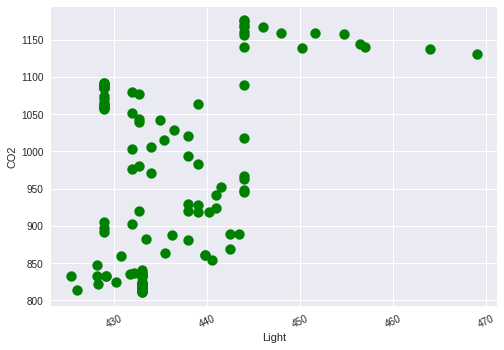

In [35]:
x = []
y = []
  
with open('occupancy.csv','r') as csvfile:
    numberOflines = len([line for line in csvfile])
    csvfile.seek(0)
    r = csv.reader(csvfile)
    next(r, None)
    for index, row in enumerate(r):
        if (index > 80 and index < 190):
            x.append(row[3])
            y.append(row[4])
            numberOflines -=1
  
x = [round(float(num), 4) for num in x]
y = [round(float(num), 4) for num in y]
plt.scatter(x, y, color = 'g', s = 100)
plt.xticks(rotation = 25)
plt.xlabel('Light')
plt.ylabel('CO2')
plt.title('', fontsize = 20)
#plt.xlim(0, 20)
plt.show()

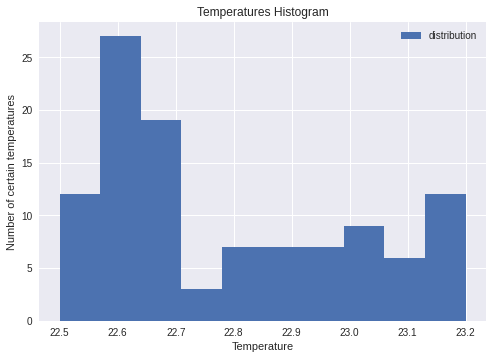

In [36]:
x = []
y = []
  
with open('occupancy.csv','r') as csvfile:
    numberOflines = len([line for line in csvfile])
    csvfile.seek(0)
    r = csv.reader(csvfile)
    for index, row in enumerate(r):
        if (index > 80 and index < 190):
            x.append(row[1])
            numberOflines -=1
  
x = [round(float(num), 4) for num in x]
legend = ['distribution']
plt.hist(x) 
plt.xlabel("Temperature")
plt.ylabel("Number of certain temperatures")
plt.legend(legend)
plt.title('Temperatures Histogram')
#plt.ylim(0, 5)
#plt.xlim(0, 5)
plt.show()

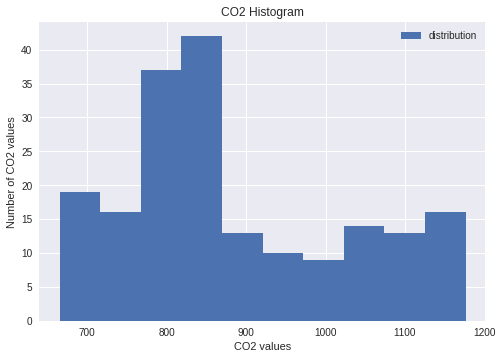

In [37]:
x = []
y = []
  
with open('occupancy.csv','r') as csvfile:
    numberOflines = len([line for line in csvfile])
    csvfile.seek(0)
    r = csv.reader(csvfile)
    for index, row in enumerate(r):
        if (index > 80 and index < 270):
            x.append(row[4])
            numberOflines -=1
  
x = [round(float(num), 4) for num in x]
legend = ['distribution']
plt.hist(x) 
plt.xlabel("CO2 values")
plt.ylabel("Number of CO2 values")
plt.legend(legend)
plt.title('CO2 Histogram')
#plt.ylim(0, 5)
#plt.xlim(0, 5)
plt.show()

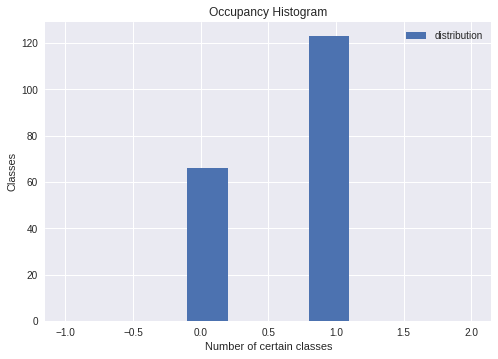

In [38]:
x = []
y = []
  
with open('occupancy.csv','r') as csvfile:
    numberOflines = len([line for line in csvfile])
    csvfile.seek(0)
    r = csv.reader(csvfile)
    for index, row in enumerate(r):
        if (index > 80 and index < 270):
            x.append(row[6])
            numberOflines -=1
  
x = [round(float(num), 4) for num in x]
legend = ['distribution']
plt.hist(x, range=[-1, 2]) 
plt.xlabel("Number of certain classes")
plt.ylabel("Classes")
plt.legend(legend)
plt.title('Occupancy Histogram')
#plt.ylim(0, 5)
#plt.xlim(0, 5)
plt.show()

/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


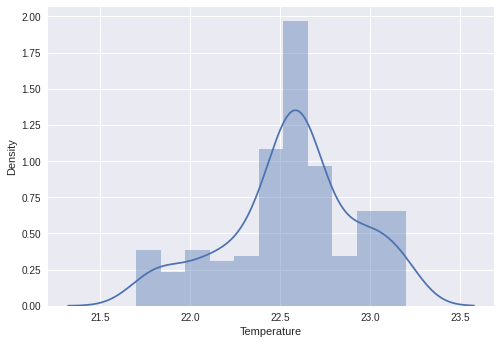

In [39]:
# PART 2 
# z-score standarization (normalization)
# value = valie - mean / std

sns.distplot(df['Temperature'])

/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


     Temperature  Humidity     Light       CO2  HumidityRatio  Occupancy
0       1.775324  1.928246  0.747312  1.704140       1.971227          1
1       1.775324  1.907488  0.747312  1.747971       1.955382          1
2       1.775324  1.962843  0.720022  1.802136       1.997637          1
3       1.775324  1.962843  0.679086  1.844897       1.997637          1
4       1.775324  1.975298  0.681815  1.816390       2.007145          1
..           ...       ...       ...       ...            ...        ...
185    -2.199915 -1.019377 -1.812555 -1.412112      -1.347004          0
186    -2.199915 -1.036676 -1.812555 -1.463783      -1.359065          0
187    -2.255513 -1.047055 -1.812555 -1.544673      -1.375988          0
188    -2.394507 -1.088571 -1.812555 -1.564130      -1.443489          0
189    -2.394507 -1.088571 -1.812555 -1.570687      -1.443489          0

[190 rows x 6 columns]


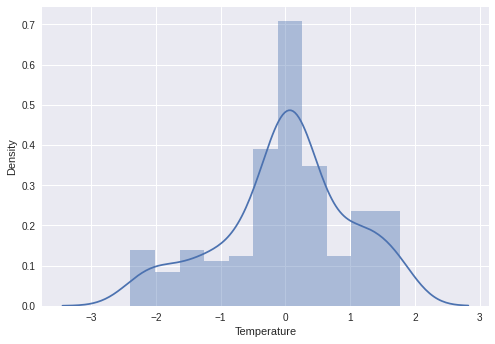

In [40]:
df2 = df.copy()
for col in ['Temperature', 'Humidity', 'Light',	'CO2',	'HumidityRatio']:
  df2[col] = (df2[col] - df2[col].mean()) / df2[col].std()

sns.distplot(df2['Temperature'])
print(df2)

In [41]:
# min-max normalization
df4 = df.copy()
df4.drop('Occupancy', inplace=True, axis=1) # without occupancy
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(df4)
# print(normalized_data)
df3 = pd.DataFrame(normalized_data, columns=df4.columns)

extracted_col = df['Occupancy']
df3 = df3.join(extracted_col)

print(df3)

     Temperature  Humidity     Light       CO2  HumidityRatio  Occupancy
0       1.000000  0.911181  1.000000  0.898479       0.962805          1
1       1.000000  0.904911  1.000000  0.910504       0.958337          1
2       1.000000  0.921630  0.989339  0.925365       0.970251          1
3       1.000000  0.921630  0.973348  0.937097       0.970251          1
4       1.000000  0.925392  0.974414  0.929275       0.972932          1
..           ...       ...       ...       ...            ...        ...
185     0.046667  0.020899  0.000000  0.043506       0.027205          0
186     0.046667  0.015674  0.000000  0.029330       0.023804          0
187     0.033333  0.012539  0.000000  0.007137       0.019032          0
188     0.000000  0.000000  0.000000  0.001799       0.000000          0
189     0.000000  0.000000  0.000000  0.000000       0.000000          0

[190 rows x 6 columns]


In [42]:
# for classification !!!
# k-fold cross-validation

X = df3.iloc[:,:-1]   # or df3 df2
Y = df3.iloc[:,-1]    # or df3 df2
   
k = 28 # subsets
k_fold = KFold(n_splits = k, random_state = None)  
Lr = LogisticRegression(solver = 'liblinear')  
   
acc_scores = []  

for training_index, testing_index in k_fold.split(X):  
    X_train, X_test = X.iloc[training_index,:], X.iloc[testing_index,:]  
    Y_train, Y_test = Y.iloc[training_index] , Y.iloc[testing_index]  
      
    # lab = preprocessing.LabelEncoder()
    # Y_train2 = lab.fit_transform(Y_train) 
    Lr.fit(X_train,Y_train)  
    Y_pred = Lr.predict(X_test)  
       
    # Y_test2 = lab.fit_transform(Y_test)
    acc = accuracy_score(Y_pred , Y_test)  
    acc_scores.append(acc)  
      
mean_acc_score = sum(acc_scores) / k  
   
print("Accuracy score of each fold: ", acc_scores)  
print("Mean accuracy score: ", mean_acc_score)  

Accuracy score of each fold:  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.42857142857142855, 0.0, 0.0, 0.2857142857142857, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Mean accuracy score:  0.8826530612244897


In [43]:
# MULTI-LAYER PERCEPTRON 
# PREDICTION

x_all = df3.drop(['Occupancy'], axis=1).values
y_all = keras.utils.np_utils.to_categorical(df3['Occupancy'].values)

y_all_0 = y_all[y_all[:,1]==0]
y_all_1 = y_all[y_all[:,1]==1]
x_all   = np.concatenate([x_all[y_all[:,1]==0], np.repeat(x_all[y_all[:,1]==1], repeats=int(len(y_all_0)/len(y_all_1)), axis=0)], axis=0)
y_all   = np.concatenate([y_all[y_all[:,1]==0], np.repeat(y_all[y_all[:,1]==1], repeats=int(len(y_all_0)/len(y_all_1)), axis=0)], axis=0)

x_train, x_valid, y_train, y_valid = sklearn.model_selection.train_test_split(x_all, y_all, test_size=0.2, random_state=0)

model = Sequential()
model.add(Dense(x_train.shape[1], input_dim=x_train.shape[1], activation="tanh"))
model.add(Dense(8, activation="tanh"))
model.add(Dense(2, activation="softmax"))
model.compile(loss="categorical_crossentropy", optimizer="Nadam", metrics=['mae', 'mse', 'accuracy'])
# model.build(df2.values)
# model.summary()

# Train model
history = model.fit(x_train, y_train, batch_size=32, epochs=50, validation_data=(x_valid, y_valid), verbose=1)

# Test model
test_results = model.evaluate(x_valid, y_valid, verbose=1)
print(test_results)

Epoch 1/50
2/2 [==============================] - 1s 169ms/step - loss: 0.7178 - mae: 0.5115 - mse: 0.2623 - accuracy: 0.4717 - val_loss: 0.7491 - val_mae: 0.5268 - val_mse: 0.2779 - val_accuracy: 0.0714
Epoch 2/50
2/2 [==============================] - 0s 31ms/step - loss: 0.7029 - mae: 0.5042 - mse: 0.2548 - accuracy: 0.4717 - val_loss: 0.7377 - val_mae: 0.5214 - val_mse: 0.2723 - val_accuracy: 0.0714
Epoch 3/50
2/2 [==============================] - 0s 22ms/step - loss: 0.6902 - mae: 0.4978 - mse: 0.2485 - accuracy: 0.5283 - val_loss: 0.7260 - val_mae: 0.5158 - val_mse: 0.2664 - val_accuracy: 0.0714
Epoch 4/50
2/2 [==============================] - 0s 21ms/step - loss: 0.6772 - mae: 0.4911 - mse: 0.2420 - accuracy: 0.5849 - val_loss: 0.7138 - val_mae: 0.5098 - val_mse: 0.2603 - val_accuracy: 0.2143
Epoch 5/50
2/2 [==============================] - 0s 19ms/step - loss: 0.6637 - mae: 0.4842 - mse: 0.2353 - accuracy: 0.6226 - val_loss: 0.7011 - val_mae: 0.5036 - val_mse: 0.2540 - val_a

In [44]:
y = y_train.copy()
print(y)

[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [45]:
x = x_train.copy()
x = np.round(x, 2)
x

array([[0.56, 0.18, 0.91, 0.37, 0.3 ],
       [0.29, 0.09, 0.  , 0.13, 0.15],
       [0.08, 0.03, 0.  , 0.06, 0.04],
       [0.6 , 0.19, 0.9 , 0.37, 0.32],
       [0.53, 0.13, 0.89, 0.29, 0.25],
       [0.06, 0.02, 0.  , 0.05, 0.03],
       [0.53, 0.15, 0.89, 0.31, 0.27],
       [0.35, 0.11, 0.  , 0.19, 0.18],
       [0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.19, 0.06, 0.  , 0.1 , 0.1 ],
       [0.33, 0.1 , 0.  , 0.19, 0.17],
       [0.53, 0.16, 0.9 , 0.32, 0.27],
       [0.53, 0.13, 0.89, 0.29, 0.25],
       [0.39, 0.13, 0.  , 0.23, 0.21],
       [0.37, 0.12, 0.  , 0.2 , 0.19],
       [0.39, 0.13, 0.  , 0.22, 0.21],
       [0.08, 0.04, 0.  , 0.05, 0.05],
       [0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.27, 0.08, 0.  , 0.1 , 0.13],
       [0.48, 0.1 , 0.89, 0.26, 0.21],
       [0.6 , 0.16, 0.91, 0.36, 0.3 ],
       [0.52, 0.12, 0.89, 0.27, 0.24],
       [0.56, 0.18, 0.9 , 0.35, 0.29],
       [0.51, 0.11, 0.89, 0.28, 0.23],
       [0.46, 0.09, 0.89, 0.25, 0.2 ],
       [0.05, 0.02, 0.  ,

In [46]:
# Predict test dataset
y_pred = model.predict(x_valid)
predictionT = y_pred[0]
expectedT = y_valid[0]
predictionH = y_pred[1]
expectedH = y_valid[1]
predictionL = y_pred[2]
expectedL = y_valid[2]
predictionCO = y_pred[3]
expectedCO = y_valid[3]
predictionHR = y_pred[4]
expectedHR = y_valid[4]
# Temperature	Humidity	Light	CO2	HumidityRatio
pred_result1 = pd.DataFrame({'Actual Temperature': expectedT.flatten(), 'Prediction Temperature': predictionT.flatten(), 'Actual Humidity': expectedH.flatten(), 'Prediction Humidity': predictionH.flatten(), 
                             'Actual Light': expectedL.flatten(), 'Prediction Light': predictionL.flatten(), 'Actual CO2': expectedCO.flatten(), 'Prediction CO2': predictionCO.flatten(),
                             'Actual Humidity Ratio': expectedHR.flatten(), 'Prediction Humidity Ratio': predictionHR.flatten()})
pred_result1

1/1 [==============================] - 0s 66ms/step


,Actual Temperature,Prediction Temperature,Actual Humidity,Prediction Humidity,Actual Light,Prediction Light,Actual CO2,Prediction CO2,Actual Humidity Ratio,Prediction Humidity Ratio
0,1.0,0.798043,1.0,0.748672,1.0,0.787182,1.0,0.792535,1.0,0.793623
1,0.0,0.201958,0.0,0.251328,0.0,0.212818,0.0,0.207465,0.0,0.206377


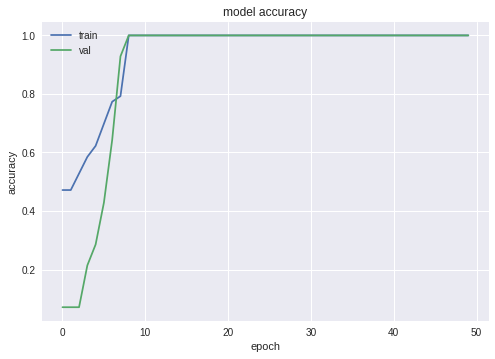

In [47]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

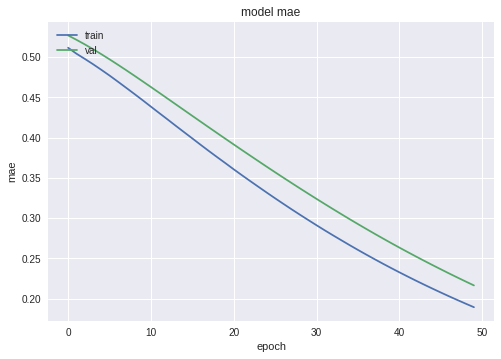

In [48]:
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('model mae')
plt.ylabel('mae')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

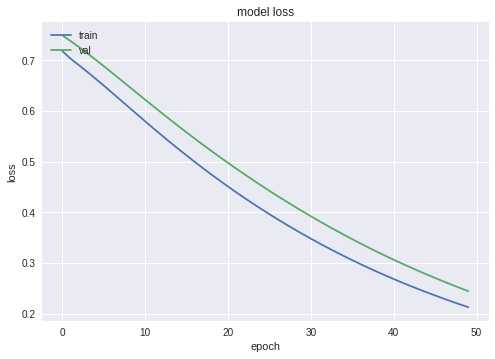

In [49]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

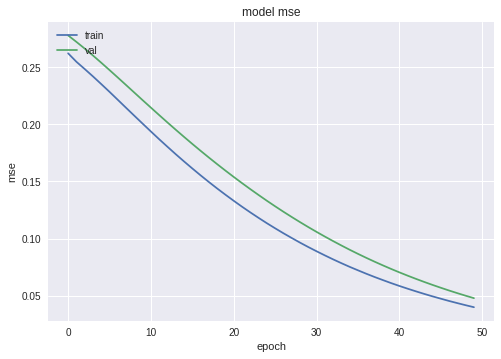

In [50]:
plt.plot(history.history['mse'])
plt.plot(history.history['val_mse'])
plt.title('model mse')
plt.ylabel('mse')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [51]:
# MULTI-LAYER PERCEPTRON 
# CLASSIFICATION

x_all = df3.drop(['Occupancy'], axis=1).values
y_all = keras.utils.np_utils.to_categorical(df3['Occupancy'].values)

X_train, X_test, Y_train, Y_test = sklearn.model_selection.train_test_split(x_all, y_all, random_state=0)

model = Sequential()
model.add(Dense(X_train.shape[1], input_dim=X_train.shape[1], activation="tanh"))
model.add(Dense(130, activation="tanh"))
model.add(Dense(120, activation="tanh"))
model.add(Dense(90, activation="tanh"))
model.add(Dense(70, activation="tanh"))
model.add(Dense(20, activation="tanh"))
model.add(Dense(10, activation="tanh"))
model.add(Dense(2, activation="softmax"))
model.compile(loss="categorical_crossentropy", optimizer="Nadam", metrics=['mae', 'mse', 'accuracy'])
# model.build(df2.values)
# model.summary()

# Train model
history = model.fit(X_train, Y_train, batch_size=32, epochs=150, validation_data=(X_test, Y_test), verbose=1)

# Test model
test_results2 = model.evaluate(X_test, Y_test, verbose=1)
print(test_results2)

Epoch 1/150
5/5 [==============================] - 1s 55ms/step - loss: 0.5998 - mae: 0.4236 - mse: 0.2076 - accuracy: 0.6127 - val_loss: 0.5256 - val_mae: 0.3684 - val_mse: 0.1746 - val_accuracy: 0.6875
Epoch 2/150
5/5 [==============================] - 0s 7ms/step - loss: 0.5144 - mae: 0.3598 - mse: 0.1699 - accuracy: 0.6901 - val_loss: 0.4799 - val_mae: 0.3166 - val_mse: 0.1564 - val_accuracy: 0.7708
Epoch 3/150
5/5 [==============================] - 0s 7ms/step - loss: 0.4583 - mae: 0.3222 - mse: 0.1449 - accuracy: 0.8169 - val_loss: 0.4119 - val_mae: 0.2792 - val_mse: 0.1258 - val_accuracy: 0.8750
Epoch 4/150
5/5 [==============================] - 0s 7ms/step - loss: 0.3892 - mae: 0.2797 - mse: 0.1151 - accuracy: 0.8803 - val_loss: 0.4082 - val_mae: 0.2203 - val_mse: 0.1209 - val_accuracy: 0.8750
Epoch 5/150
5/5 [==============================] - 0s 7ms/step - loss: 0.3437 - mae: 0.2299 - mse: 0.1007 - accuracy: 0.8803 - val_loss: 0.3539 - val_mae: 0.1908 - val_mse: 0.1058 - val_a

In [52]:
y2 = Y_train.copy()
for i in range(len(y2)):
  for j in range(len(y2[i])):
      if j == 0:
        if y2[i][j] > 0:
          y2[i][j] = 1
print(y2)

[[0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 

In [53]:
x2 = X_train.copy()
x2 = np.round(x2, 2)
x2

array([[0.46, 0.07, 0.89, 0.21, 0.19],
       [0.67, 0.38, 0.94, 0.5 , 0.47],
       [0.15, 0.04, 0.  , 0.08, 0.07],
       [0.46, 0.09, 0.89, 0.23, 0.2 ],
       [0.87, 0.74, 0.92, 0.76, 0.79],
       [0.46, 0.2 , 0.88, 0.26, 0.28],
       [0.6 , 0.16, 0.92, 0.33, 0.29],
       [0.67, 0.45, 0.95, 0.58, 0.52],
       [0.37, 0.12, 0.  , 0.2 , 0.19],
       [0.93, 0.76, 0.95, 0.93, 0.83],
       [0.68, 0.5 , 0.92, 0.62, 0.56],
       [0.6 , 0.15, 0.92, 0.34, 0.29],
       [0.52, 0.12, 0.89, 0.27, 0.24],
       [0.79, 0.69, 0.92, 0.74, 0.73],
       [0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.85, 0.76, 0.91, 0.78, 0.8 ],
       [0.53, 0.13, 0.89, 0.29, 0.25],
       [0.33, 0.09, 0.  , 0.18, 0.16],
       [0.46, 0.09, 0.89, 0.25, 0.2 ],
       [0.6 , 0.18, 0.94, 0.37, 0.31],
       [0.59, 0.16, 0.92, 0.29, 0.29],
       [0.53, 0.13, 0.89, 0.29, 0.25],
       [0.87, 0.8 , 0.91, 0.82, 0.83],
       [0.59, 0.17, 0.92, 0.31, 0.29],
       [0.59, 0.16, 0.92, 0.33, 0.29],
       [0.73, 0.58, 0.93,

In [54]:
# Predict test dataset
y_pred2 = model.predict(X_test)
predictionT2 = y_pred2[0]
expectedT2 = Y_test[0]
predictionH2 = y_pred2[1]
expectedH2 = Y_test[1]
predictionL2 = y_pred2[2]
expectedL2 = Y_test[2]
predictionCO2 = y_pred2[3]
expectedCO2 = Y_test[3]
predictionHR2 = y_pred2[4]
expectedHR2 = Y_test[4]
# Temperature	Humidity	Light	CO2	HumidityRatio
pred_result2 = pd.DataFrame({'Actual Temperature': expectedT2.flatten(), 'Prediction Temperature': predictionT2.flatten(), 'Actual Humidity': expectedH2.flatten(), 'Prediction Humidity': predictionH2.flatten(), 
                             'Actual Light': expectedL2.flatten(), 'Prediction Light': predictionL2.flatten(), 'Actual CO2': expectedCO2.flatten(), 'Prediction CO2': predictionCO2.flatten(),
                             'Actual Humidity Ratio': expectedHR2.flatten(), 'Prediction Humidity Ratio': predictionHR2.flatten()})
pred_result2

2/2 [==============================] - 0s 4ms/step


,Actual Temperature,Prediction Temperature,Actual Humidity,Prediction Humidity,Actual Light,Prediction Light,Actual CO2,Prediction CO2,Actual Humidity Ratio,Prediction Humidity Ratio
0,0.0,0.318266,0.0,0.074422,1.0,0.996046,0.0,0.296002,1.0,0.375841
1,1.0,0.681734,1.0,0.925578,0.0,0.003954,1.0,0.703998,0.0,0.624159


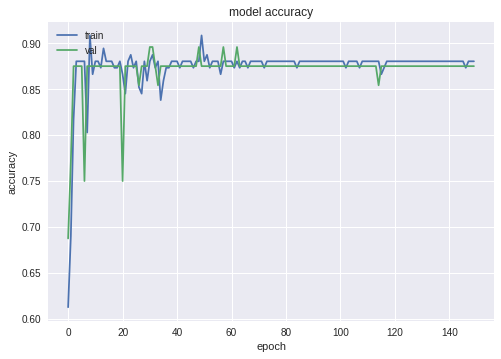

In [55]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

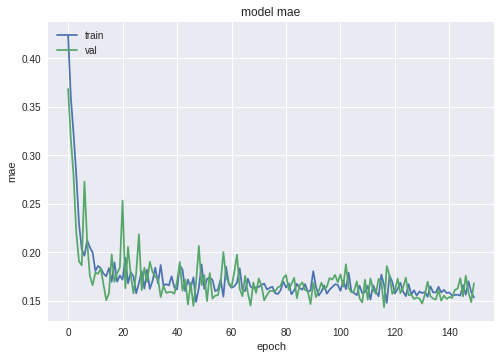

In [56]:
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('model mae')
plt.ylabel('mae')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

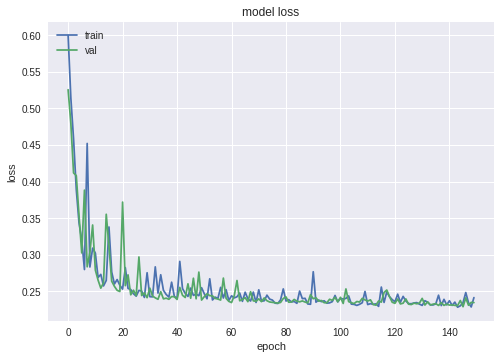

In [57]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

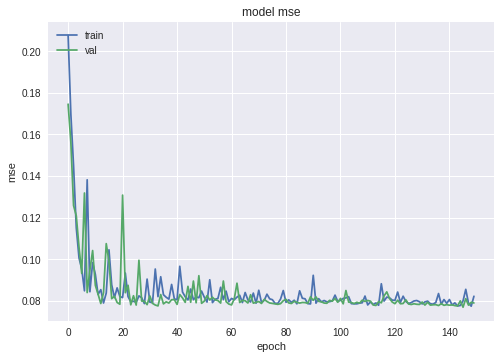

In [58]:
plt.plot(history.history['mse'])
plt.plot(history.history['val_mse'])
plt.title('model mse')
plt.ylabel('mse')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

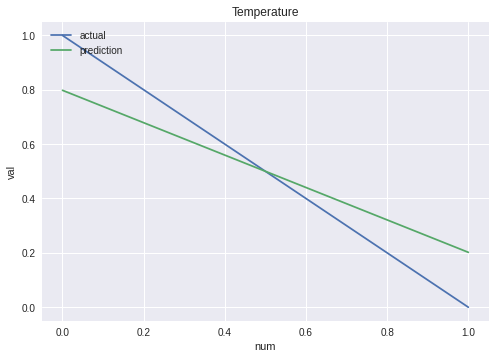

In [59]:
plt.plot(pred_result1['Actual Temperature'])
plt.plot(pred_result1['Prediction Temperature'])
plt.title('Temperature')
plt.ylabel('val')
plt.xlabel('num')
plt.legend(['actual', 'prediction'], loc='upper left')
plt.show()

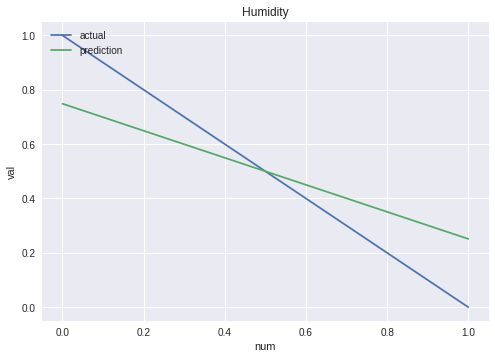

In [60]:
plt.plot(pred_result1['Actual Humidity'])
plt.plot(pred_result1['Prediction Humidity'])
plt.title('Humidity')
plt.ylabel('val')
plt.xlabel('num')
plt.legend(['actual', 'prediction'], loc='upper left')
plt.show()

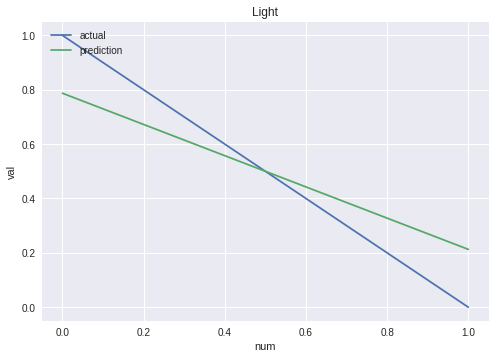

In [61]:
plt.plot(pred_result1['Actual Light'])
plt.plot(pred_result1['Prediction Light'])
plt.title('Light')
plt.ylabel('val')
plt.xlabel('num')
plt.legend(['actual', 'prediction'], loc='upper left')
plt.show()

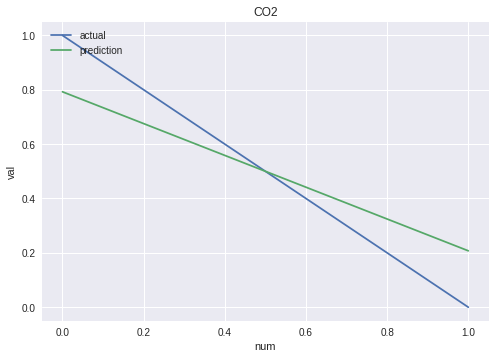

In [62]:
plt.plot(pred_result1['Actual CO2'])
plt.plot(pred_result1['Prediction CO2'])
plt.title('CO2')
plt.ylabel('val')
plt.xlabel('num')
plt.legend(['actual', 'prediction'], loc='upper left')
plt.show()

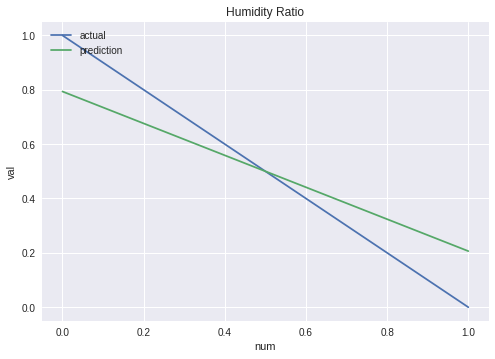

In [63]:
plt.plot(pred_result1['Actual Humidity Ratio'])
plt.plot(pred_result1['Prediction Humidity Ratio'])
plt.title('Humidity Ratio')
plt.ylabel('val')
plt.xlabel('num')
plt.legend(['actual', 'prediction'], loc='upper left')
plt.show()

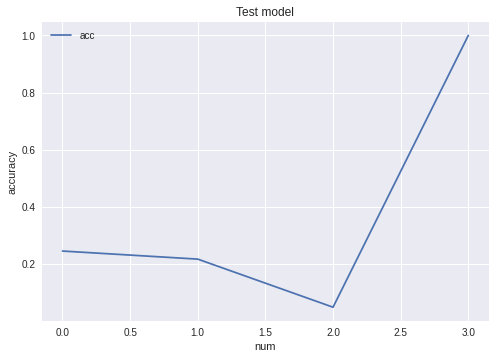

In [64]:
plt.plot(test_results)
plt.title('Test model')
plt.ylabel('accuracy')
plt.xlabel('num')
plt.legend(['acc'], loc='upper left')
plt.show()

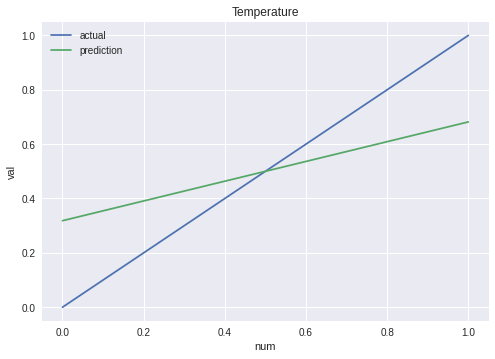

In [65]:
plt.plot(pred_result2['Actual Temperature'])
plt.plot(pred_result2['Prediction Temperature'])
plt.title('Temperature')
plt.ylabel('val')
plt.xlabel('num')
plt.legend(['actual', 'prediction'], loc='upper left')
plt.show()

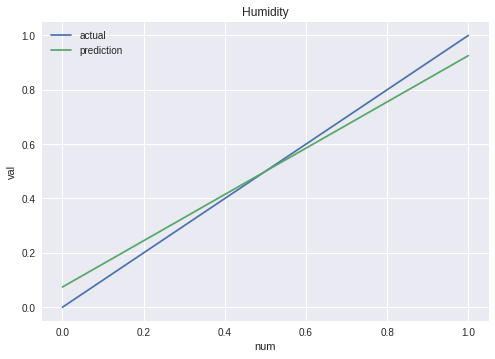

In [66]:
plt.plot(pred_result2['Actual Humidity'])
plt.plot(pred_result2['Prediction Humidity'])
plt.title('Humidity')
plt.ylabel('val')
plt.xlabel('num')
plt.legend(['actual', 'prediction'], loc='upper left')
plt.show()

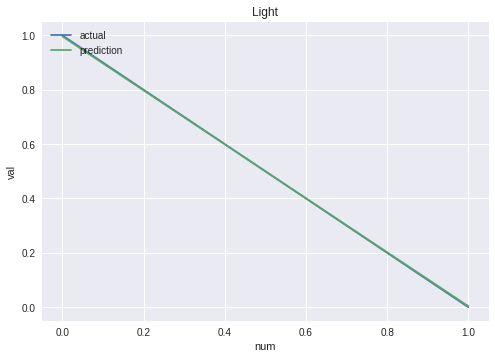

In [67]:
plt.plot(pred_result2['Actual Light'])
plt.plot(pred_result2['Prediction Light'])
plt.title('Light')
plt.ylabel('val')
plt.xlabel('num')
plt.legend(['actual', 'prediction'], loc='upper left')
plt.show()

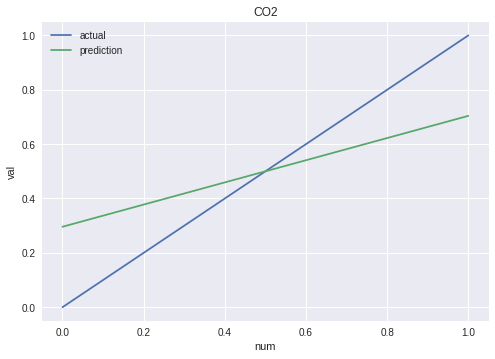

In [68]:
plt.plot(pred_result2['Actual CO2'])
plt.plot(pred_result2['Prediction CO2'])
plt.title('CO2')
plt.ylabel('val')
plt.xlabel('num')
plt.legend(['actual', 'prediction'], loc='upper left')
plt.show()

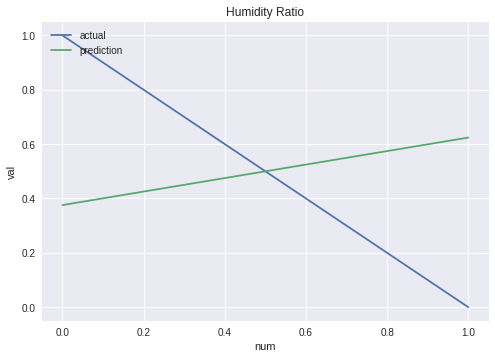

In [69]:
plt.plot(pred_result2['Actual Humidity Ratio'])
plt.plot(pred_result2['Prediction Humidity Ratio'])
plt.title('Humidity Ratio')
plt.ylabel('val')
plt.xlabel('num')
plt.legend(['actual', 'prediction'], loc='upper left')
plt.show()

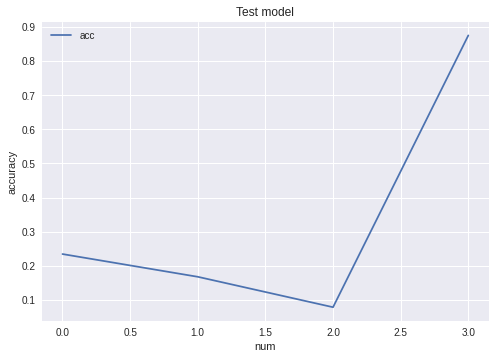

In [70]:
plt.plot(test_results2)
plt.title('Test model')
plt.ylabel('accuracy')
plt.xlabel('num')
plt.legend(['acc'], loc='upper left')
plt.show()